## 1. Conceptual Explanation of Stochastic Gradient Descent (SGD)

SGD updates the model after each training example, instead of the whole dataset.

## 2. Implement Batch Stochastic Gradient Descent From Scratch

# 2.1 Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time


## 2.2 READ & LOAD CSV FILE

In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 2.3 Prepare Data

In [4]:
# data
X = dataset["area_sqft"].values
y = dataset["house_price_inr"].values

# normalization
X = (X - X.mean()) / X.std()

n = len(X)

## 2.4 Initialize Parameters

In [5]:
# parameters
w = 0
b = 0

learning_rate = 0.01
epochs = 50

cost_history_sgd = []

start = time.time()

## 2.5 Stochastic Gradient Descent Algorithm

In [6]:
for epoch in range(epochs):

    for i in range(n):

        xi = X[i]
        yi = y[i]

        y_pred = w * xi + b

        dw = -2 * xi * (yi - y_pred)
        db = -2 * (yi - y_pred)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    y_pred_all = w * X + b
    cost = np.mean((y - y_pred_all)**2)

    cost_history_sgd.append(cost)

end = time.time()

sgd_time = end - start

print("SGD slope:", w)
print("SGD intercept:", b)
print("Training Time:", sgd_time)

SGD slope: 9963612.339877341
SGD intercept: 23964973.6255892
Training Time: 0.25380563735961914


## 2.6 Predicted Values

In [7]:
y_pred_sgd = w * X + b

result_sgd = pd.DataFrame({
    "Actual Price": y,
    "Predicted Price": y_pred_sgd
})

print(result_sgd.astype(int))

      Actual Price  Predicted Price
0         40275084         29243184
1         26812029         22267793
2         29315677         30898362
3         46250249         40508526
4         17724566         21220640
...            ...              ...
4195      18319188         18349413
4196      40340976         35830116
4197       6189628          6594274
4198       7916191          6155145
4199      34319843         30053883

[4200 rows x 2 columns]


## Graph 1 — Regression Line from stochastic Gradient Descent

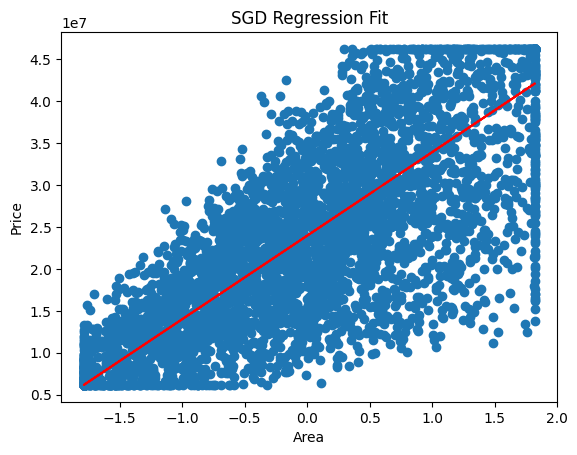

In [8]:
plt.scatter(X, y)

plt.plot(X, y_pred_sgd, color="red")

plt.title("SGD Regression Fit")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

## Graph 2 - SGD Convergence Graph

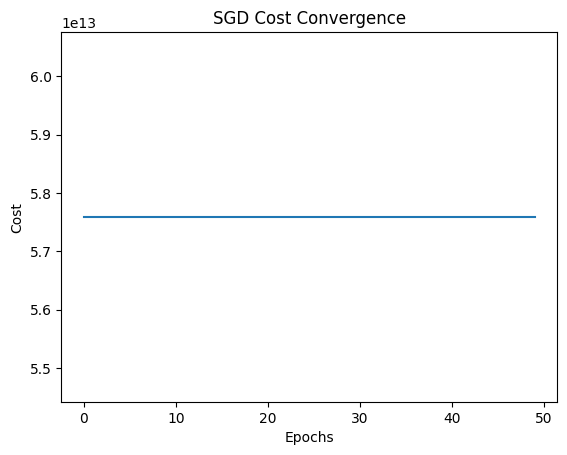

In [9]:
plt.plot(cost_history_sgd)

plt.title("SGD Cost Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

## 2.7 Calculate Evaluation Metrics

## [A] Mean squared error

In [10]:
mse = mean_squared_error(y,y_pred_sgd)
print(f"Mean squared error : {mse}")

Mean squared error : 57591542684756.74


Mean Squared Error (MSE) calculates the average of squared errors, giving more importance to larger errors.

## [B] Mean absolute error

In [11]:
mae = mean_absolute_error(y,y_pred_sgd)
print(f"Mean absolute error : {mae}")

Mean absolute error : 5862854.985290585


Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

## [C] Root mean sqaured error

In [12]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 7588909.189386624


 Root Mean Squared Error (RMSE) is the square root of MSE and provides error values in the same units as the target variable.

## [D] R2 Score

In [13]:
r2 = r2_score(y,y_pred_sgd)
print(f"R2 score : {r2}")

R2 score : 0.5502133674183769


The R² Score indicates the proportion of variance in the target variable that is explained by the model. 

In [14]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 55.021336741837686%


## [E] Adjusted r2 score

In [15]:
# Number of samples and predictors
n = len(y)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.5501062243424879


Adjusted R² Score further adjusts the R² value based on the number of predictors used in the model.